Saved outputs are retained from the original experiments; they have not been regenerated with the cleaned implementation. Set data and checkpoint paths below before running.

In [ ]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "count_fm").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from types import SimpleNamespace

# 1. read data

In [2]:
def load_struct(path: Path, varname: str = None):
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)
    keys = [k for k in mat.keys() if not k.startswith("__")]

    if varname is not None and varname in mat:
        return mat[varname]

    if len(keys) == 1:
        v = mat[keys[0]]
        if hasattr(v, "_fieldnames"):  # matlab struct
            return v

    return SimpleNamespace(**{k: mat[k] for k in keys})


def bank_of(p: Path):
    m = re.search(r"_bank(\d+)\.(efd|resp|st)$", p.name)
    return int(m.group(1)) if m else None

def safe_len(x):
    try:
        return int(np.asarray(x).size)
    except Exception:
        return None

def load_session_all(sess_dir: Path):
    sess_dir = Path(sess_dir)
    assert sess_dir.exists(), f"Session folder not found: {sess_dir}"

    efd_files  = sorted(sess_dir.glob("*.efd"))
    resp_files = sorted(sess_dir.glob("*.resp"))
    st_files   = sorted(sess_dir.glob("*.st"))

    print("Session:", sess_dir)
    print("Found:", len(efd_files), "efd |", len(resp_files), "resp |", len(st_files), "st")

    # group by bank id (if present)
    banks = sorted(set([bank_of(p) for p in efd_files + resp_files + st_files if bank_of(p) is not None]))
    if not banks:
        banks = [None]  # fallback: no bank tag in filenames

    out = {"banks": {}}

    for b in banks:
        def pick(files, ext):
            if not files:
                return None
        
            # 1) exact bank match if possible
            if b is not None:
                for p in files:
                    if bank_of(p) == b:
                        return p
        
            # 2) fallback: if there is exactly one file (resp often looks like 141208-2.resp), use it
            if len(files) == 1:
                return files[0]
        
            # 3) fallback: prefer a file with no bank tag (again, resp)
            for p in files:
                if bank_of(p) is None:
                    return p
        
            return None


        efd_p  = pick(efd_files,  "efd")
        resp_p = pick(resp_files, "resp")
        st_p   = pick(st_files,   "st")

        bank_key = f"bank{b}" if b is not None else "bank?"
        out["banks"][bank_key] = {"paths": {"efd": efd_p, "resp": resp_p, "st": st_p}}

        print("\n==", bank_key, "==")
        print("  efd :", efd_p.name  if efd_p  else None)
        print("  resp:", resp_p.name if resp_p else None)
        print("  st  :", st_p.name   if st_p   else None)

        # --- load efd ---
        if efd_p:
            efd = load_struct(efd_p, "efd")
            out["banks"][bank_key]["efd"] = efd

            # core odor-aligned raster (already aligned: -5..10s around inhale; 0=inhalation) :contentReference[oaicite:2]{index=2}
            vs = getattr(efd, "ValveSpikes", None)
            raster = getattr(vs, "RasterAlign", None) if vs is not None else None
            if raster is not None:
                n_odors, n_units = raster.shape
                n_trials = int(raster[0, 0].size)
                print(f"  ValveSpikes.RasterAlign: n_odors={n_odors}, n_units={n_units}, n_trials={n_trials}")
            else:
                print("  ValveSpikes.RasterAlign: MISSING")

            # valve timing fields (odor on/off and alignment inhale time) :contentReference[oaicite:3]{index=3}
            vt = getattr(efd, "ValveTimes", None)
            if vt is not None:
                on  = getattr(vt, "FVSwitchTimesOn", None)
                off = getattr(vt, "FVSwitchTimesOff", None)
                prex_times = getattr(vt, "PREXTimes", None)
                print("  ValveTimes: On/Off/PREXTimes present?",
                      on is not None, off is not None, prex_times is not None)

            # laser timing/spikes (only relevant if opto pulses exist) :contentReference[oaicite:4]{index=4}
            lt = getattr(efd, "LaserTimes", None)
            if lt is not None and getattr(lt, "LaserOn", None) is not None:
                n_pulses = safe_len(getattr(lt, "LaserOn"))
                print("  LaserTimes: pulses =", n_pulses)
            else:
                print("  LaserTimes: none/empty")

            # breathstats is session-level summary :contentReference[oaicite:5]{index=5}
            bs = getattr(efd, "BreathStats", None)
            print("  BreathStats present?", bs is not None)

            # PREX in efd is redundant with resp.PREX :contentReference[oaicite:6]{index=6}
            prex_efd = getattr(efd, "PREX", None)
            if prex_efd is not None:
                print("  efd.PREX length:", safe_len(prex_efd))

        # --- load resp ---
        if resp_p:
            resp = load_struct(resp_p, "resp")
            out["banks"][bank_key]["resp"] = resp

            # resp contains RRR, PREX, POSTX, and breath-by-breath features :contentReference[oaicite:7]{index=7}
            RRR   = getattr(resp, "RRR", None)
            PREX  = getattr(resp, "PREX", None)
            POSTX = getattr(resp, "POSTX", None)
            BbyB  = getattr(resp, "BbyB", None)
            print("  resp: RRR/PREX/POSTX present?", RRR is not None, PREX is not None, POSTX is not None)
            print("  resp lengths: PREX=", safe_len(PREX), "POSTX=", safe_len(POSTX), "RRR=", safe_len(RRR))
            if BbyB is not None:
                # breath features Height/Width/Slope :contentReference[oaicite:8]{index=8}
                h = getattr(BbyB, "Height", None)
                w = getattr(BbyB, "Width", None)
                s = getattr(BbyB, "Slope", None)
                print("  resp.BbyB present? Height/Width/Slope:",
                      h is not None, w is not None, s is not None)

        # --- load st ---
        if st_p:
            try:
                st = load_struct(st_p, "SpikeTimes")  # works for non-v7.3
                out["banks"][bank_key]["st"] = st
                tsec = getattr(st, "tsec", None)
                stwarped = getattr(st, "stwarped", None)
                units = getattr(st, "units", None)
                n_cells = safe_len(tsec) if tsec is not None else None
                print("  SpikeTimes: tsec present?", tsec is not None, "stwarped present?", stwarped is not None)
                if n_cells is not None:
                    print("  SpikeTimes.tsec cells =", n_cells)
                if units is not None:
                    print("  SpikeTimes.units length:", safe_len(units))
            except NotImplementedError:
                print("  SpikeTimes: MATLAB v7.3 (HDF5). loadmat can't read it. We'll parse with h5py later.")

    return out

In [3]:
sess_dir = Path("/home/ganchao/isilon/AllStaff/ganchao/recurrent_stablize/pcx/141208-2")
data = load_session_all(sess_dir)

Session: /home/ganchao/isilon/AllStaff/ganchao/recurrent_stablize/pcx/141208-2
Found: 1 efd | 1 resp | 1 st

== bank2 ==
  efd : 141208-2_bank2.efd
  resp: 141208-2.resp
  st  : 141208-2_bank2.st
  ValveSpikes.RasterAlign: n_odors=16, n_units=85, n_trials=30
  ValveTimes: On/Off/PREXTimes present? True True True
  LaserTimes: none/empty
  BreathStats present? True
  efd.PREX length: 8608
  resp: RRR/PREX/POSTX present? True True True
  resp lengths: PREX= 8608 POSTX= 8608 RRR= 9624552
  resp.BbyB present? Height/Width/Slope: True True True
  SpikeTimes: MATLAB v7.3 (HDF5). loadmat can't read it. We'll parse with h5py later.


# 2. check respiration

Estimated fs (Hz) = 2000.5703709739378


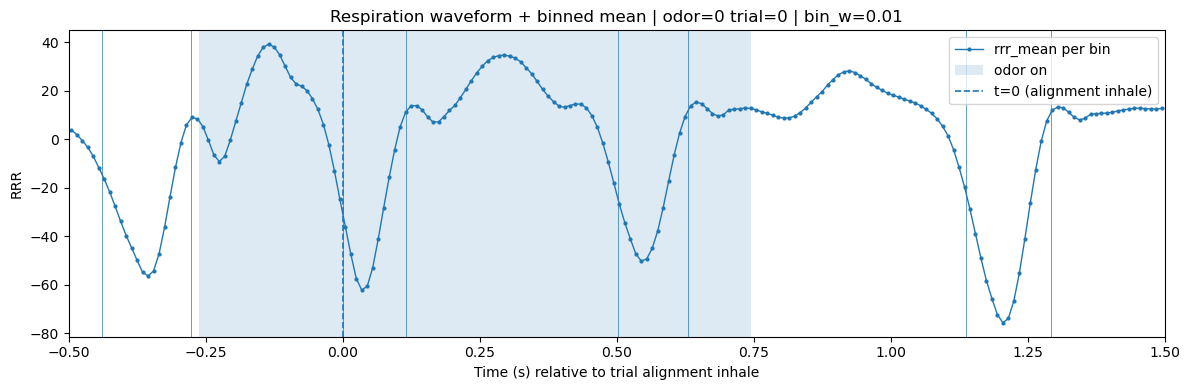

In [4]:
bank_key = list(data["banks"].keys())[0]
efd  = data["banks"][bank_key]["efd"]
resp = data["banks"][bank_key]["resp"]

vt = efd.ValveTimes
vs = efd.ValveSpikes

RRR   = np.asarray(resp.RRR).astype(float).ravel()
PREX  = np.asarray(resp.PREX).astype(float).ravel()
POSTX = np.asarray(resp.POSTX).astype(float).ravel()

BbyB = resp.BbyB
WIDTH  = np.asarray(getattr(BbyB, "Width")).astype(float).ravel()   # len ~ PREX-1
HEIGHT = np.asarray(getattr(BbyB, "Height")).astype(float).ravel()
SLOPE  = np.asarray(getattr(BbyB, "Slope")).astype(float).ravel()

# estimate fs from time span (avoids hard-coding 2000)
fs = len(RRR) / (PREX.max() - PREX.min())
print("Estimated fs (Hz) =", fs)

# --------- pick one trial ----------
odor = 0
tr = 0

prex0_abs = float(np.asarray(vt.PREXTimes.flat[odor]).astype(float).ravel()[tr])
t_on_abs  = float(np.asarray(vt.FVSwitchTimesOn.flat[odor]).astype(float).ravel()[tr])
t_off_abs = float(np.asarray(vt.FVSwitchTimesOff.flat[odor]).astype(float).ravel()[tr])

# spike binning window (relative to t=0 = this trial's alignment inhale)
tmin, tmax = -0.5, 1.5
bin_w = 0.01

edges = np.arange(tmin, tmax + bin_w, bin_w)
t_centers = 0.5 * (edges[:-1] + edges[1:])
T = len(t_centers)

# absolute times of bin edges
edges_abs = prex0_abs + edges

# --------- helper: map absolute time -> RRR sample index ----------
def time_to_idx(t_abs):
    # assume RRR sample 0 corresponds to recording time 0 (consistent with PREX times)
    idx = np.floor(t_abs * fs).astype(int)
    return np.clip(idx, 0, len(RRR))

# --------- binned rrr_mean (only) ----------
i0 = time_to_idx(edges_abs[:-1])
i1 = time_to_idx(edges_abs[1:])

# cumulative sum for fast bin means
# (handle any zero-length bins defensively)
cs = np.concatenate([[0.0], np.cumsum(RRR)])
counts = (i1 - i0)
rrr_mean = np.zeros(T, dtype=float)
good = counts > 0
rrr_mean[good] = (cs[i1[good]] - cs[i0[good]]) / counts[good]
rrr_mean[~good] = np.nan

# --------- bin-aligned breath covariates from PREX/POSTX/BbyB ----------
# convert breath event times to trial-relative
prex_rel  = PREX  - prex0_abs
postx_rel = POSTX - prex0_abs

# For each bin center t, find the most recent PREX index i such that PREX[i] <= t
i = np.searchsorted(prex_rel, t_centers, side="right") - 1
valid = (i >= 0) & (i < len(prex_rel)-1) & (i < len(WIDTH))

# inhale indicator: t in [PREX_i, POSTX_i)
is_inhale = np.full(T, np.nan, dtype=float)
is_inhale[valid] = (t_centers[valid] < postx_rel[i[valid]]).astype(float)

# per-bin period/amp/slope: take breath-level values for the current breath index i
period = np.full(T, np.nan, dtype=float)
amp    = np.full(T, np.nan, dtype=float)
slope  = np.full(T, np.nan, dtype=float)
period[valid] = WIDTH[i[valid]]
amp[valid]    = HEIGHT[i[valid]]
slope[valid]  = SLOPE[i[valid]]

# (optional, for visualization only) two phase definitions
phase_prex = np.full(T, np.nan, dtype=float)   # PREX->next PREX, in [0,1)
phase_ie   = np.full(T, np.nan, dtype=float)   # PREX->POSTX->next PREX, in [0,1)
if np.any(valid):
    prev = prex_rel[i[valid]]
    nxt  = prex_rel[i[valid] + 1]
    denom = (nxt - prev)
    ok = denom > 1e-6
    tmp = np.full(prev.shape, np.nan, dtype=float)
    tmp[ok] = (t_centers[valid][ok] - prev[ok]) / denom[ok]
    phase_prex[valid] = tmp

    # inhale half [0,0.5), exhale half [0.5,1)
    post = postx_rel[i[valid]]
    inh = t_centers[valid] < post
    # inhale segment
    denom_inh = (post - prev)
    ok_inh = denom_inh > 1e-6
    ph = np.full(prev.shape, np.nan, dtype=float)
    ph[inh & ok_inh] = 0.5 * (t_centers[valid][inh & ok_inh] - prev[inh & ok_inh]) / denom_inh[inh & ok_inh]
    # exhale segment
    denom_exh = (nxt - post)
    ok_exh = denom_exh > 1e-6
    ph[(~inh) & ok_exh] = 0.5 + 0.5 * (t_centers[valid][(~inh) & ok_exh] - post[(~inh) & ok_exh]) / denom_exh[(~inh) & ok_exh]
    phase_ie[valid] = ph

# odor window (relative)
t_on = t_on_abs - prex0_abs
t_off = t_off_abs - prex0_abs

# --------- plot 1: RRR waveform segment + binned rrr_mean ----------
plt.figure(figsize=(12, 4))
plt.plot(t_centers, rrr_mean, marker="o", markersize=2, linewidth=1.0, label="rrr_mean per bin")

# event markers within window
m_prex = (prex_rel >= tmin) & (prex_rel <= tmax)
m_post = (postx_rel >= tmin) & (postx_rel <= tmax)
for tt in prex_rel[m_prex]:
    plt.axvline(tt, linewidth=0.5)
for tt in postx_rel[m_post]:
    plt.axvline(tt, linewidth=0.5)

plt.axvspan(t_on, t_off, alpha=0.15, label="odor on")
plt.axvline(0.0, linestyle="--", linewidth=1.2, label="t=0 (alignment inhale)")
plt.xlim(tmin, tmax)
plt.xlabel("Time (s) relative to trial alignment inhale")
plt.ylabel("RRR")
plt.title(f"Respiration waveform + binned mean | odor={odor} trial={tr} | bin_w={bin_w}")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

# 3. Prepare for regression

In [5]:
bank_key = list(data["banks"].keys())[0]
efd  = data["banks"][bank_key]["efd"]
resp = data["banks"][bank_key]["resp"]

vt = efd.ValveTimes
vs = efd.ValveSpikes
raster = vs.RasterAlign                     # (n_odors, n_units) object

RRR   = np.asarray(resp.RRR).astype(float).ravel()
PREX  = np.asarray(resp.PREX).astype(float).ravel()
POSTX = np.asarray(resp.POSTX).astype(float).ravel()

n_odors, n_units = raster.shape
n_trials = int(raster[0, 0].size)

# drop unit 0 (multiunit aggregate)
unit_ids = np.arange(1, n_units)

# -------- binning (fixed window) --------
tmin, tmax = -0.5, 1.5
bin_w = 0.01

edges = np.arange(tmin, tmax + bin_w, bin_w)
t_centers = 0.5 * (edges[:-1] + edges[1:])

# -------- trial alignment + odor on/off (absolute seconds) --------
prex0_by_odor = vt.PREXTimes
on_by_odor    = vt.FVSwitchTimesOn
off_by_odor   = vt.FVSwitchTimesOff

# -------- estimate respiration sampling rate from time span --------
fs = len(RRR) / (PREX.max() - PREX.min())
print("Estimated respiration fs (Hz) =", fs)

# precompute cumsum for fast mean-in-bin
cs = np.concatenate([[0.0], np.cumsum(RRR)])

def time_to_idx(t_abs):
    idx = np.floor(t_abs * fs).astype(int)
    return np.clip(idx, 0, len(RRR))

X_list, C_list, meta_list = [], [], []   # meta_list stores (odor, trial)

for odor in range(n_odors):
    prex0_vec = np.asarray(prex0_by_odor.flat[odor]).astype(float).ravel()
    on_vec    = np.asarray(on_by_odor.flat[odor]).astype(float).ravel()
    off_vec   = np.asarray(off_by_odor.flat[odor]).astype(float).ravel()

    Ttr = min(len(prex0_vec), len(on_vec), len(off_vec), n_trials)

    for tr in range(Ttr):
        prex0_abs = float(prex0_vec[tr])  # absolute time of alignment inhale (t=0)
        t_on  = float(on_vec[tr]  - prex0_abs)
        t_off = float(off_vec[tr] - prex0_abs)

        # ---- X: binned spikes (T, N) ----
        X = np.zeros((len(t_centers), len(unit_ids)), dtype=np.int32)
        for j, u in enumerate(unit_ids):
            spk = np.asarray(raster[odor, u].flat[tr]).astype(float).ravel()
            X[:, j] = np.histogram(spk, bins=edges)[0]

        # ---- rrr_mean per bin ----
        edges_abs = prex0_abs + edges
        i0 = time_to_idx(edges_abs[:-1])
        i1 = time_to_idx(edges_abs[1:])
        denom = (i1 - i0)

        rrr_mean = np.full(len(t_centers), np.nan, dtype=float)
        good = denom > 0
        rrr_mean[good] = (cs[i1[good]] - cs[i0[good]]) / denom[good]

        # ---- inhale indicator per bin ----
        prex_rel  = PREX  - prex0_abs
        postx_rel = POSTX - prex0_abs

        breath_idx = np.searchsorted(prex_rel, t_centers, side="right") - 1
        valid = (breath_idx >= 0) & (breath_idx < len(prex_rel) - 1) & (breath_idx < len(postx_rel))

        is_inhale = np.full(len(t_centers), np.nan, dtype=float)
        is_inhale[valid] = (t_centers[valid] < postx_rel[breath_idx[valid]]).astype(float)

        # ---- other covariates ----
        odor_present = ((t_centers >= t_on) & (t_centers <= t_off)).astype(float)
        odor_id = np.full_like(t_centers, odor, dtype=float)

        # C columns: [t, rrr_mean, odor_present, odor_id, is_inhale]
        C_raw = np.column_stack([t_centers, rrr_mean, odor_present, odor_id, is_inhale])

        # ---- drop rows with any NaNs/infs in covariates ----
        keep = np.isfinite(C_raw).all(axis=1)
        if not np.any(keep):
            continue

        X = X[keep, :]
        C = C_raw[keep, :]

        X_list.append(X)
        C_list.append(C)
        meta_list.append((odor, tr))

print("k =", len(X_list))
print("X shape =", X_list[0].shape, "C shape =", C_list[0].shape)
print("C columns = ['t','rrr_mean','odor_present','odor_id','is_inhale']")
print("example meta_list[0] =", meta_list[0])

Estimated respiration fs (Hz) = 2000.5703709739378
k = 480
X shape = (200, 84) C shape = (200, 5)
C columns = ['t','rrr_mean','odor_present','odor_id','is_inhale']
example meta_list[0] = (0, 0)


In [6]:
save_path = "pcx_141208-2_bank2_XC_bin001.npz"

np.savez_compressed(
    save_path,
    X_list=np.array(X_list, dtype=object),
    C_list=np.array(C_list, dtype=object),
    meta_list=np.array(meta_list, dtype=object),
    C_columns=np.array(["t","rrr_mean","odor_present","odor_id","is_inhale"], dtype=object),
)

print("saved to:", save_path)

saved to: pcx_141208-2_bank2_XC_bin001.npz
